<a href="https://colab.research.google.com/github/kuunalmistry/Google_Colab_Clg_Experiments_Projects/blob/main/Kuunal_Mistry_2410130_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
from skimage.util import random_noise
from google.colab.patches import cv2_imshow

In [ ]:
img = cv2.imread("/content/IMG_4255.png")

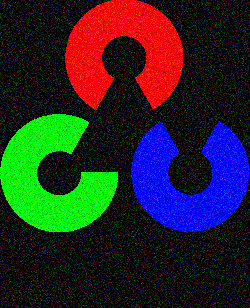

In [ ]:
# Gaussian Noise
gaussian = random_noise(img, mode='gaussian', mean=0, var=0.02)
gaussian = np.array(255*gaussian, dtype=np.uint8)
cv2_imshow(gaussian)

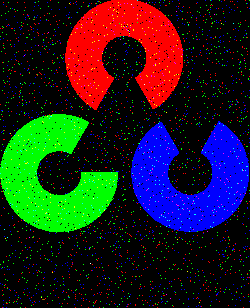

In [ ]:
# Salt and Pepper
snp = random_noise(img, mode='s&p', amount=0.03)
snp = np.array(255*snp, dtype=np.uint8)
cv2_imshow(snp)

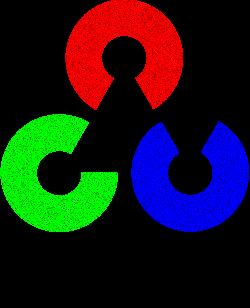

In [ ]:
# Speckle
speckle = random_noise(img, mode='speckle', var=0.04)
speckle = np.array(255*speckle, dtype=np.uint8)
cv2_imshow(speckle)

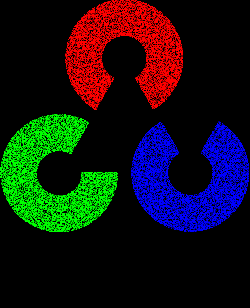

In [ ]:
# Poisson
poison = random_noise(img, mode='poisson')
poison = np.array(255*poison, dtype=np.uint8)
cv2_imshow(poison)

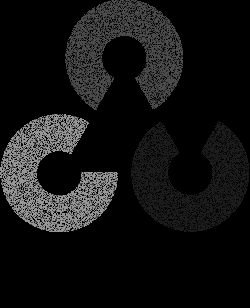

In [ ]:
# Converting image from color to grayscale
img2 = cv2.cvtColor(poison, cv2.COLOR_BGR2GRAY)
cv2_imshow(img2)

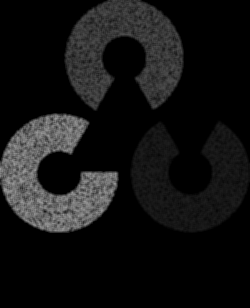

In [ ]:
# Average Filter - Low-pass filtering
lpf = cv2.blur(img2,(3,3))
cv2_imshow(lpf)

In [ ]:
# Getting the image dimensions
m, n = img2.shape
print(f"Image dimensions: {m}x{n}")

Image dimensions: 308x250


In [ ]:
# Making the mask
mask = np.ones([3,3], dtype=int)
mask = mask/9

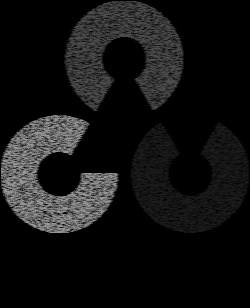

In [ ]:
img3 = np.zeros((m,n))
for i in range(1,m-1):
  for j in range(1,n-1):
    img3[i,j] = (mask*img2[i-1, j-1:j+2]).sum()
cv2_imshow(img3)